# MOVIE RATING PREDICTION WITH PYTHON

In [46]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns




In [47]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [48]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Loding the dataset

In [49]:
df = pd.read_csv(r"C:\Users\Aayushi\Downloads\IMDb Movies India.csv.zip" , encoding = "latin1")


# Remove Unnecessary Coloumns 

In [50]:
df = df.drop(columns=["Name", "Year", "Duration"], errors="ignore")

In [51]:
df.head()

,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


# Remove Missing Rating

In [52]:
df = df.dropna(subset=["Rating"])

# Reducing the dataset

In [73]:
df_small = df.sample(n=2000, random_state=42)

# Exploring the dataset

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7919 entries, 1 to 15508
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Genre     7817 non-null   object 
 1   Rating    7919 non-null   float64
 2   Votes     7919 non-null   object 
 3   Director  7914 non-null   object 
 4   Actor 1   7794 non-null   object 
 5   Actor 2   7719 non-null   object 
 6   Actor 3   7627 non-null   object 
dtypes: float64(1), object(6)
memory usage: 494.9+ KB


In [75]:
df.shape

(7919, 7)

In [76]:
df.describe()

,Rating
count,7919.000000
mean,5.841621
std,1.381777
min,1.100000
25%,4.900000
50%,6.000000
75%,6.800000
max,10.000000


In [77]:
df.isnull()

,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
1,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False
6,False,False,False,False,False,False,False
8,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
15501,False,False,False,False,False,False,False
15503,False,False,False,False,False,False,False
15504,False,False,False,False,False,False,False
15505,False,False,False,False,False,False,False


In [78]:
df.isnull().sum()

Genre       102
Rating        0
Votes         0
Director      5
Actor 1     125
Actor 2     200
Actor 3     292
dtype: int64

# Feature Selection

In [79]:
features = [
    "Genre",
    "Director",
    "Actor 1",
    "Actor 2",
    "Actor 3"
]

X = df[features]

y = df["Rating"]

In [80]:
X.head()

,Genre,Director,Actor 1,Actor 2,Actor 3
1,Drama,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
3,"Comedy, Romance",Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
5,"Comedy, Drama, Musical",Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor
6,"Drama, Romance, War",Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma
8,"Horror, Mystery, Thriller",Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia


In [81]:
y.head()

1    7.0
3    4.4
5    4.7
6    7.4
8    5.6
Name: Rating, dtype: float64

# Preprocessing

In [82]:
categorical_features = features

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("cat", categorical_transformer, categorical_features)
])

# Build Model

In [83]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

# Train test split

In [84]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [85]:
X_train.shape

(6335, 5)

In [86]:
X_test.shape

(1584, 5)

In [87]:
y_train.shape

(6335,)

In [88]:
y_test.shape

(1584,)

In [89]:
X_train.head()

,Genre,Director,Actor 1,Actor 2,Actor 3
8157,"Comedy, Drama",Ronit Jadhav,Ronit Jadhav,Rohit D'Souza,Darshil Gandhi
8455,Drama,Shibu Mitra,Shashi Kapoor,Pran,Amjad Khan
14490,"Drama, War",Kabir Khan,Salman Khan,Sohail Khan,Om Puri
2697,Action,Gautam Verma,Rajat Bedi,Mithun Chakraborty,Dinesh Hingoo
15470,"Documentary, Biography, Musical",Sandip Ray,Kishore Kumar,Amitabh Bachchan,Asha Bhosle


In [90]:
X_test.head()

,Genre,Director,Actor 1,Actor 2,Actor 3
9456,Romance,Gautam Siddhartha,Akshay Anand,Sangeeta Ghosh,Amjad Khan
14816,"Action, Biography, Crime",Ram Gopal Varma,Sachiin Joshi,Sandeep Bharadwaj,Usha Jadhav
3213,"Action, Adventure, Thriller",Aditya Datt,Vidyut Jammwal,Adah Sharma,Gulshan Devaiah
3778,Drama,Ashwini Chaudhary,Om Puri,Revathi,Gul Panag
5775,Horror,Suraj Bharti,Sahilraj Dewangen,Johnny Janarden,Shubham Kathe


In [91]:
y_train.head()

8157     8.8
8455     6.0
14490    3.8
2697     5.8
15470    8.2
Name: Rating, dtype: float64

In [92]:
y_test.head()

9456     3.3
14816    5.3
3213     5.7
3778     7.2
5775     3.5
Name: Rating, dtype: float64

# Train the Model

In [93]:
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


# Make Predictions

In [94]:
y_pred = model.predict(X_test)

In [95]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", round(mae,3))
print("MSE :", round(mse,3))
print("RMSE:", round(rmse,3))
print("R² Score:", round(r2,3))

MAE : 0.937
MSE : 1.465
RMSE: 1.21
R² Score: 0.212


# Actual VS Predicted 

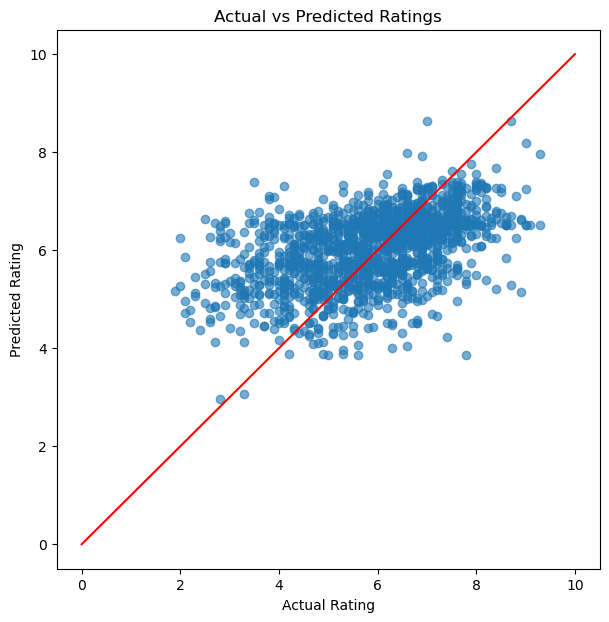

In [97]:
plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.plot([0,10],[0,10], color='red')

plt.xlabel("Actual Rating")

plt.ylabel("Predicted Rating")

plt.title("Actual vs Predicted Ratings")

plt.show()

In [98]:
new_movie = pd.DataFrame({
    "Genre": ["Drama"],
    "Director": ["Rajkumar Hirani"],
    "Actor 1": ["Aamir Khan"],
    "Actor 2": ["Madhavan"],
    "Actor 3": ["Sharman Joshi"]
})

prediction = model.predict(new_movie)

print("Predicted Rating:", round(prediction[0],2))

Predicted Rating: 6.59
